In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn import svm
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np

In [2]:

from ucimlrepo import fetch_ucirepo 
# fetch dataset 
census_income = fetch_ucirepo(id=20) 
# data (as pandas dataframes) 
X = census_income.data.features 
y = census_income.data.targets 

In [3]:
print(census_income.metadata.num_instances)
print(census_income.metadata.additional_info.summary)
print(census_income.variables) 

48842
Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

Prediction task is to determine whether a person makes over 50K a year.
              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer              NaN   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer          

In [4]:
df = pd.concat([X, y], axis=1)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [5]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(29)

In [7]:
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()
print(df['income'].unique())

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

In [9]:
df_cleaned = df.dropna(inplace=True)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,0
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,0


In [10]:
X = df.drop('income', axis=1)
y = df['income']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [12]:
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
nominal_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)  
    ],
    remainder='drop'
)


In [13]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naïve Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(dual=False, random_state=42, max_iter=2000),
    "Logistic Regression": LogisticRegression(),
    "ANN": MLPClassifier(max_iter=500, random_state=42, early_stopping=True)
}

param_grids = {
    "Decision Tree": {
        "classifier__max_depth": [3, 5, 10, None],
        "classifier__criterion": ["gini", "entropy"]
    },
    "Naïve Bayes": {},  
    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10, 100],
        "classifier__penalty": ['l2']
    },
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ['liblinear', 'saga']
    },
    "ANN": {
    'classifier__hidden_layer_sizes': [(50,)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__alpha': [0.0001, 0.05],
    'classifier__learning_rate': ['constant', 'adaptive']
    }
}

# Cross-validation dengan Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan hasil evaluasi
results = {}

# Iterasi untuk setiap model
for model_name, model in models.items():
    print(f"\n🔹 Training model: {model_name}...")

    # Untuk Naïve Bayes, kita TIDAK menggunakan SMOTE karena tidak cocok
    if model_name == "Naïve Bayes":
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('classifier', model)
        ])
    else:
        # Model lain menggunakan SMOTE untuk menangani class imbalance
        pipeline = ImbPipeline([
            ('preprocessing', preprocessor),
            ('classifier', model)
        ])

    # GridSearchCV untuk mencari hyperparameter terbaik
    grid_search = RandomizedSearchCV(pipeline, param_grids[model_name], cv=cv, scoring='accuracy', n_jobs=-1, n_iter=8)

    # Train model dengan GridSearchCV
    grid_search.fit(X_train, y_train)

    # Evaluasi di test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Simpan hasil evaluasi
    results[model_name] = {
        "best_model": best_model,
        "best_params": grid_search.best_params_,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    }

    print(f"✅ Best Params: {grid_search.best_params_}")
    print(f"✅ Accuracy: {results[model_name]['accuracy']:.2f}")
    print(f"✅ Classification Report:\n{results[model_name]['classification_report']}")


🔹 Training model: Decision Tree...
✅ Best Params: {'classifier__max_depth': 10, 'classifier__criterion': 'gini'}
✅ Accuracy: 0.86
✅ Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7217
           1       0.77      0.59      0.67      2308

    accuracy                           0.86      9525
   macro avg       0.83      0.77      0.79      9525
weighted avg       0.85      0.86      0.85      9525


🔹 Training model: Naïve Bayes...


c:\Users\- LENOVO -\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=8. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Best Params: {}
✅ Accuracy: 0.60
✅ Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.50      0.66      7217
           1       0.37      0.92      0.53      2308

    accuracy                           0.60      9525
   macro avg       0.66      0.71      0.59      9525
weighted avg       0.81      0.60      0.62      9525


🔹 Training model: KNN...
✅ Best Params: {'classifier__weights': 'uniform', 'classifier__n_neighbors': 9}
✅ Accuracy: 0.84
✅ Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      7217
           1       0.69      0.61      0.65      2308

    accuracy                           0.84      9525
   macro avg       0.79      0.76      0.77      9525
weighted avg       0.83      0.84      0.84      9525


🔹 Training model: SVM...


c:\Users\- LENOVO -\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Best Params: {'classifier__penalty': 'l2', 'classifier__C': 10}
✅ Accuracy: 0.85
✅ Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7217
           1       0.74      0.60      0.66      2308

    accuracy                           0.85      9525
   macro avg       0.81      0.77      0.78      9525
weighted avg       0.84      0.85      0.85      9525


🔹 Training model: Logistic Regression...
✅ Best Params: {'classifier__solver': 'liblinear', 'classifier__C': 100}
✅ Accuracy: 0.85
✅ Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7217
           1       0.73      0.61      0.66      2308

    accuracy                           0.85      9525
   macro avg       0.80      0.77      0.78      9525
weighted avg       0.84      0.85      0.84      9525


🔹 Training model: ANN...
✅ Best Params: {'classifier__solver': 'adam', 'classifi

In [14]:
import matplotlib.pyplot as plt

overfit_data = []

for model_name, model in models.items():
    # Bangun ulang pipeline terbaik (tanpa GridSearch, cukup estimator terbaik)
    if model_name == "Naïve Bayes":
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('classifier', model)
        ])
    else:
        pipeline = ImbPipeline([
            ('preprocessing', preprocessor),
            ('classifier', model)
        ])

    pipeline.fit(X_train, y_train)

    train_acc = pipeline.score(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)

    overfit_data.append({
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

overfit_df = pd.DataFrame(overfit_data)
overfit_df


,Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.999869,0.817953
1,Naïve Bayes,0.605287,0.601890
2,KNN,0.882665,0.833701
3,SVM,0.853055,0.851339
4,Logistic Regression,0.852189,0.849449
5,ANN,0.865393,0.856168


In [15]:
from sklearn.metrics import roc_auc_score, classification_report

metrics_data = []

for model_name, res in results.items():
    # Menggunakan .get() agar tidak KeyError. Jika tidak ada, kita beri pesan peringatan.
    best_model = res.get("best_model") 
    
    if best_model is None:
        print(f"⚠️ Peringatan: Objek model untuk {model_name} tidak ditemukan. Pastikan sudah disimpan saat training.")
        continue

    y_pred = best_model.predict(X_test)
    
    # PERBAIKAN DI SINI:
    if hasattr(best_model, "predict_proba"):
        # Ambil semua baris (:), tapi hanya kolom kedua (1)
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        # Untuk LinearSVC gunakan decision_function
        y_prob = best_model.decision_function(X_test)
    
    # Hitung AUC biner (tanpa multi_class='ovr')
    auc_score = roc_auc_score(y_test, y_prob)
    # 3. Generate report
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    metrics_data.append({
        "Model": model_name,
        "Accuracy": res["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"],
        "AUC": auc_score
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Decision Tree,0.859528,0.826529,0.769081,0.791266,0.902295
1,Naïve Bayes,0.601890,0.662299,0.711500,0.592217,0.842794
2,KNN,0.840000,0.786808,0.760469,0.771955,0.881992
3,SVM,0.851234,0.807885,0.766408,0.783414,0.903017
4,Logistic Regression,0.849554,0.803630,0.767510,0.782671,0.902882
5,ANN,0.858268,0.815149,0.783280,0.797060,0.912326


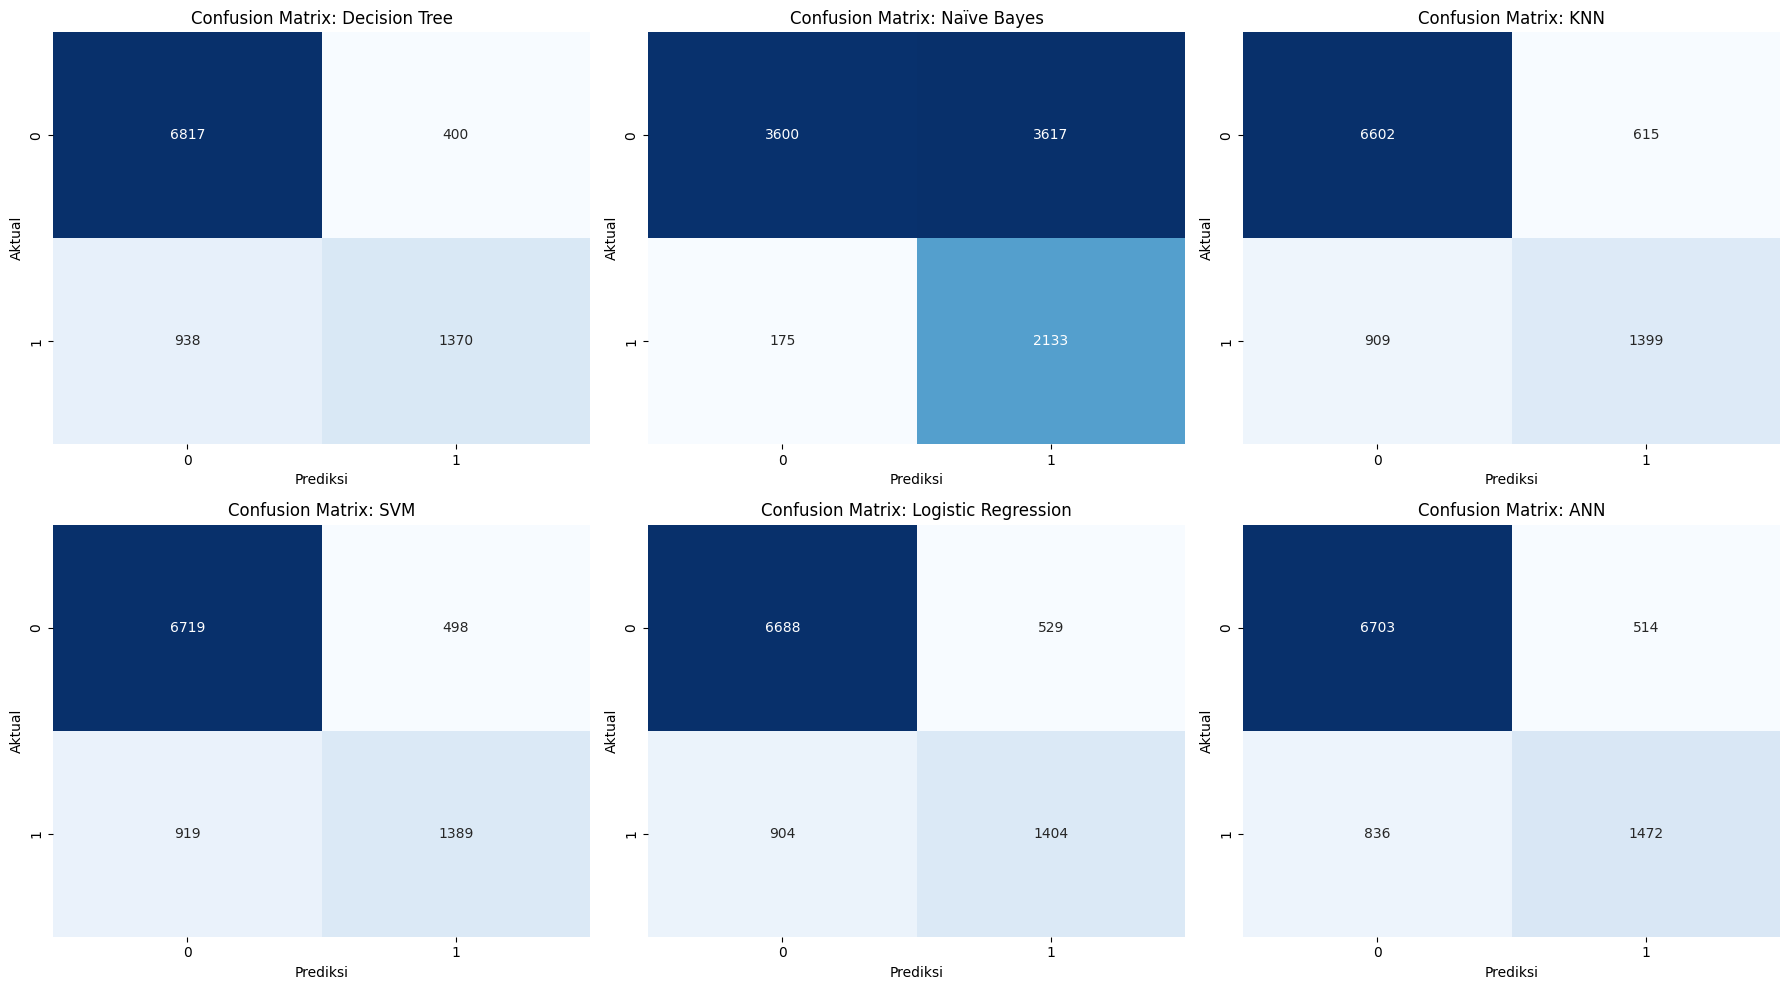

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ubah subplot menjadi 2 baris dan 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2. Ratakan axes agar mudah diakses dalam satu loop (flat array)
axes_flat = axes.flatten()

for i, (model_name, res) in enumerate(results.items()):
    best_model = res["best_model"]
    y_pred = best_model.predict(X_test)
    
    # Membuat matriks kebingungan
    cm = confusion_matrix(y_test, y_pred)
    
    # Visualisasi pada axes yang sudah diratakan
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[i], cbar=False)
    
    axes_flat[i].set_title(f'Confusion Matrix: {model_name}')
    axes_flat[i].set_xlabel('Prediksi')
    axes_flat[i].set_ylabel('Aktual')

# 3. Menghapus axes kosong jika jumlah model kurang dari 6 (opsional)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 47621 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             47621 non-null  int64
 1   workclass       47621 non-null  str  
 2   fnlwgt          47621 non-null  int64
 3   education       47621 non-null  str  
 4   education-num   47621 non-null  int64
 5   marital-status  47621 non-null  str  
 6   occupation      47621 non-null  str  
 7   relationship    47621 non-null  str  
 8   race            47621 non-null  str  
 9   sex             47621 non-null  str  
 10  capital-gain    47621 non-null  int64
 11  capital-loss    47621 non-null  int64
 12  hours-per-week  47621 non-null  int64
 13  native-country  47621 non-null  str  
 14  income          47621 non-null  int64
dtypes: int64(7), str(8)
memory usage: 5.8 MB
